### Predicting HDB Prices with Multivariate Linear Regression

Having collected the data, wrangled it together, done exploratory data analysis, we will now begin to model the data to predict HDB prices. 

In this notebook, we will be using Multivariate Linear Regression for prediction. This is a 'quick and dirty' model which is fast and reliable, with easy interpretation of model coefficients. 

The final selling price of a HDB isn’t just based on one thing - HDB size, but also factors like the number of bedrooms, the flat age, and maybe even how close it is to the MRT. This includes all the data which we have wrangled together. Multivariate linear regression is essentially using all these different pieces of information - size, bedrooms, age, location - to make a good guess at the HDB price. Each factor has its own weight in the equation, each contributing differently to the final price. 

#### **Objective:** Predict HDB Price (dependent variable) using multiple independent variables (collected data).
- **Equation for Multivariate Linear Regression**
  - Y = β₀ + β₁X₁ + β₂X₂ + ... + βₖXₖ + ε
    - Y: Dependent variable (HDB Price)
    - β₀: Y-intercept
    - β₁, β₂, ... , βₖ: Coefficients for independent variables X₁, X₂, ..., Xₖ (the weights)
    - ε: Error term
- **Assumption**
  - Assumes a linear relationship between dependent and independent variables. Involves multiple independent variables (β).
  - Assumes independence of errors, constant variance of errors (homoscedasticity), and normally distributed errors.
- **Parameters**
  - Coefficients (β) are estimated to minimize the sum of squared residuals. This is the loss function, used to create the line of best fit. 
- **Goodness of Fit**: Measured by metrics like R-squared, Mean Squared Error (MSE), Mean Absolute Error (MAE)
  - In this notebook we will use R2 and MAE.
- **Interpretation**
  - Coefficients indicate the impact/weight of each independent variable on the dependent variable.
- **Variants**
  - Multiple variations exist, including ridge and lasso regression for regularization.

#### Load Libraries

In [26]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Train Test Split
from sklearn.model_selection import train_test_split, cross_validate

# Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

# Modelling
from sklearn.linear_model import LinearRegression

# Model Evaluation
from sklearn.metrics import mean_absolute_error, r2_score
import scipy.stats as stats

# Saving Model
import pickle

import os

#### Load data into DataFrame and Remove Unwanted Columns

In [27]:
# Navigate to your project
os.chdir('/workspaces/DSE3101-Project')

# Verify you're in the right place
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Navigate to data/raw folder
os.chdir('data/raw')

Current directory: /workspaces/DSE3101-Project
Contents: ['docs', '.git', 'notebooks', '.DS_Store', 'models', 'frontend', 'requirements.txt', '.gitignore', '.vscode', 'backend', 'data', 'onemap_all_themes_full.json', 'README.md', 'onemap_all_themes_raw.txt']


In [28]:
hdb_df = pd.read_csv('HDB_full_resale_info.csv.gz')
print(hdb_df.info())

# Put all columns to be deleted into a list
drop_cols = ['block', 'street_name','address','sold_year_month']

# Drop columns
hdb_df = hdb_df.drop(columns=drop_cols, errors='ignore')

<class 'pandas.DataFrame'>
RangeIndex: 259143 entries, 0 to 259142
Data columns (total 37 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   town                               259143 non-null  str    
 1   flat_type                          259143 non-null  str    
 2   block                              259143 non-null  str    
 3   street_name                        259143 non-null  str    
 4   storey_range                       259143 non-null  str    
 5   floor_area_sqm                     259143 non-null  float64
 6   flat_model                         259143 non-null  str    
 7   lease_commence_date                259143 non-null  int64  
 8   resale_price                       259143 non-null  float64
 9   remaining_lease                    259143 non-null  int64  
 10  sold_year                          259143 non-null  int64  
 11  address                            259143 non-null

#### Prepare Data for Pipeline and Train Test Split
##### Removing Highly Correlated Features
Highly correlated features carry redundant information, which can hurt model performance and interpretability. Here's why removing them matters:

- **Reduces Redundancy** — Correlated features convey similar information, so keeping both adds noise without adding value.
- **Improves Accuracy** — Linear regression expects each feature to contribute unique information; correlated features confuse the model and distort predictions.
- **Prevents Multicollinearity** — When features are too similar, the model struggles to determine which one truly drives the outcome, skewing feature importance.
- **Simplifies the Model** — Fewer, more meaningful features make the model easier to understand, explain, and maintain.
- **Enhances Generalization** — Leaner models tend to perform better on unseen data by focusing on the most relevant signals.
- **Stabilizes Estimates** — Correlated features cause unstable and unreliable coefficient estimates; removing them leads to more consistent results.

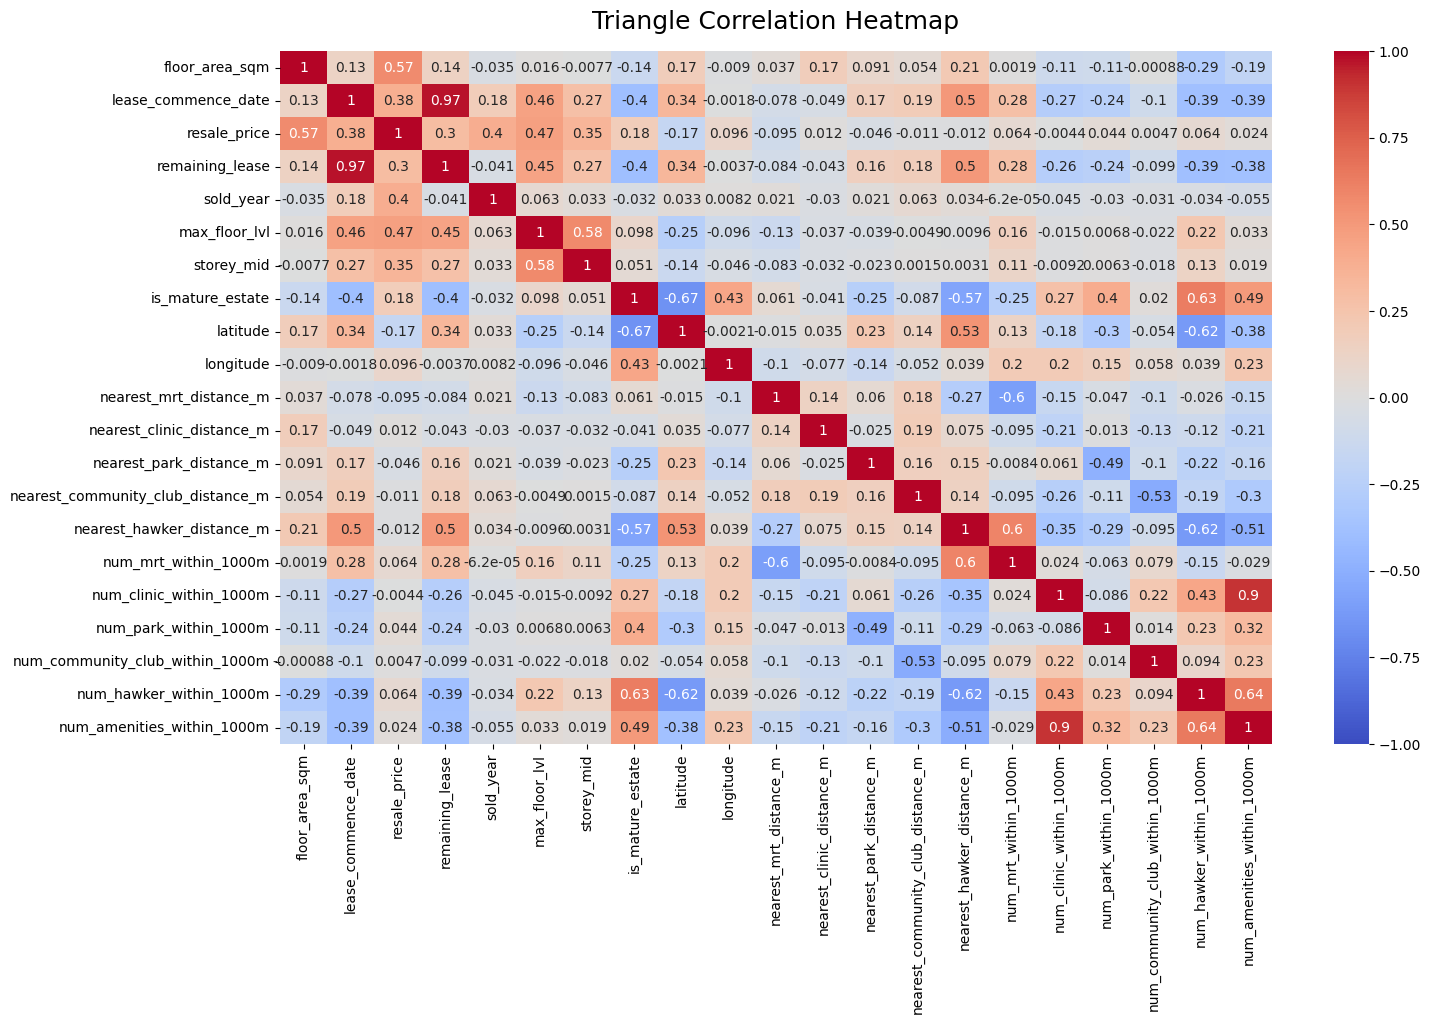

In [29]:
# Calculate the correlation matrix
correlation_matrix = hdb_df.select_dtypes(include=np.number).corr()

# Correlation coefficients
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(correlation_matrix, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

In [30]:
# Threshold for high correlation
threshold = 0.8

# Create empty list to populate
high_correlation_pairs = []

# Double for loop to get value pairs
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            # Get indexes of columns
            col_pair = (correlation_matrix.columns[i], correlation_matrix.columns[j])
            # Append to empty list
            high_correlation_pairs.append(col_pair)

# Print out the pairs of highly correlated columns
for pair in high_correlation_pairs:
    print(pair)

('remaining_lease', 'lease_commence_date')
('num_amenities_within_1000m', 'num_clinic_within_1000m')


Columns to exclude:
- 'lease_commence_date'
- 'num_clinic_within_1000m'

In [31]:
drop_cols = ['lease_commence_date','num_clinic_within_1000m']

hdb_df = hdb_df.drop(columns=drop_cols)

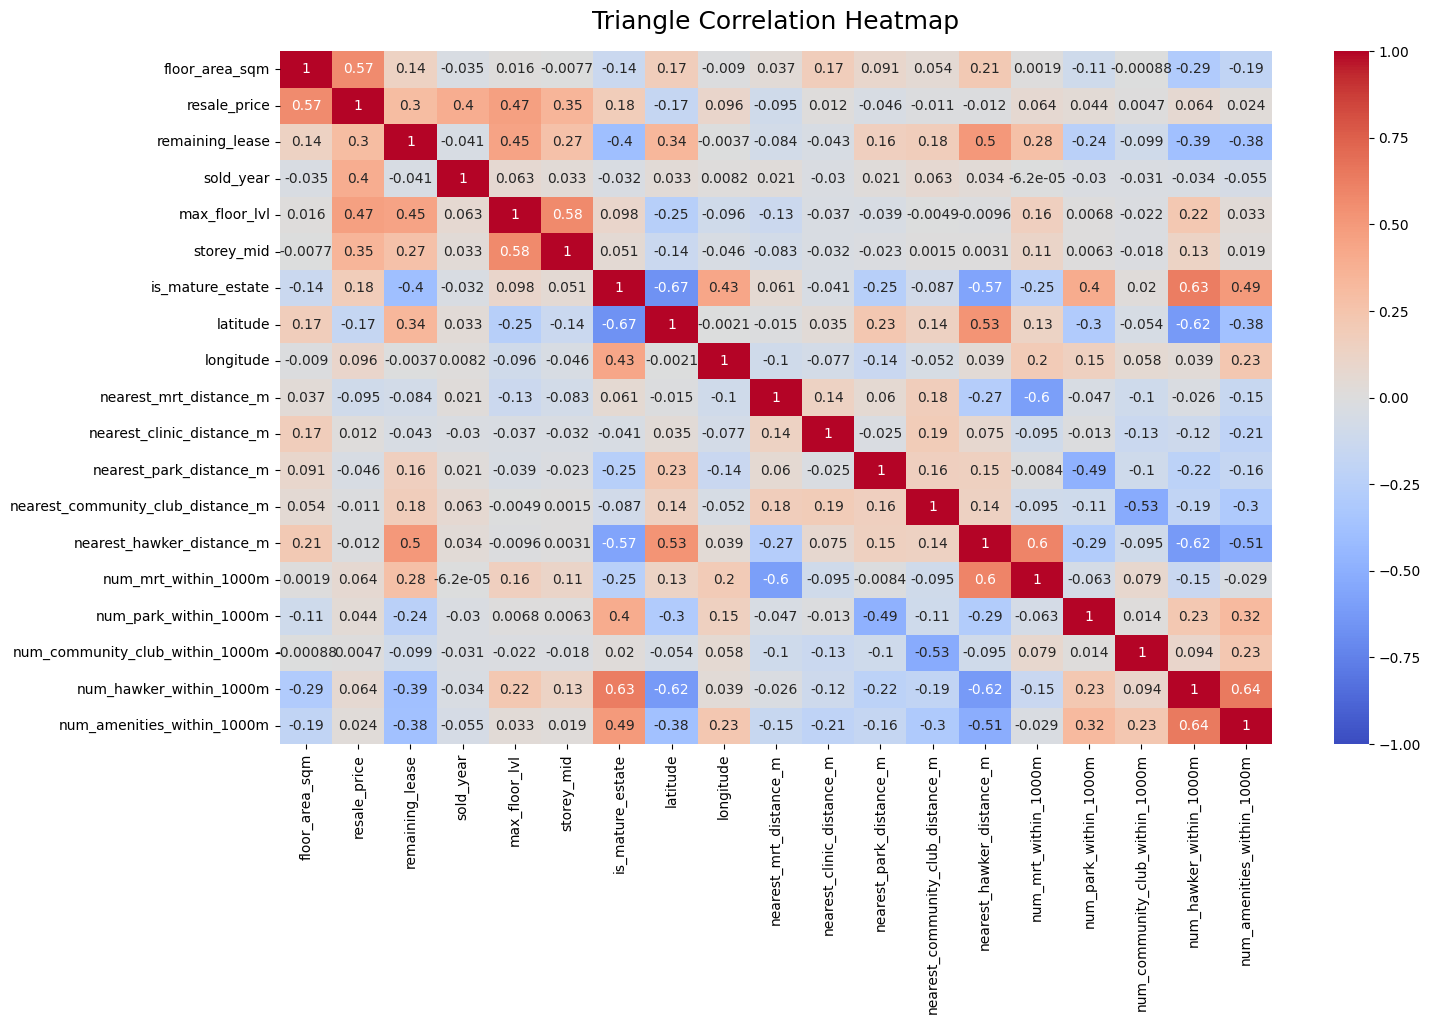

In [32]:
# Calculate the correlation matrix
correlation_matrix = hdb_df.select_dtypes(include=np.number).corr()

# Correlation coefficients
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(correlation_matrix, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

#### Visualizing Resale Price Against Other Numeric Columns

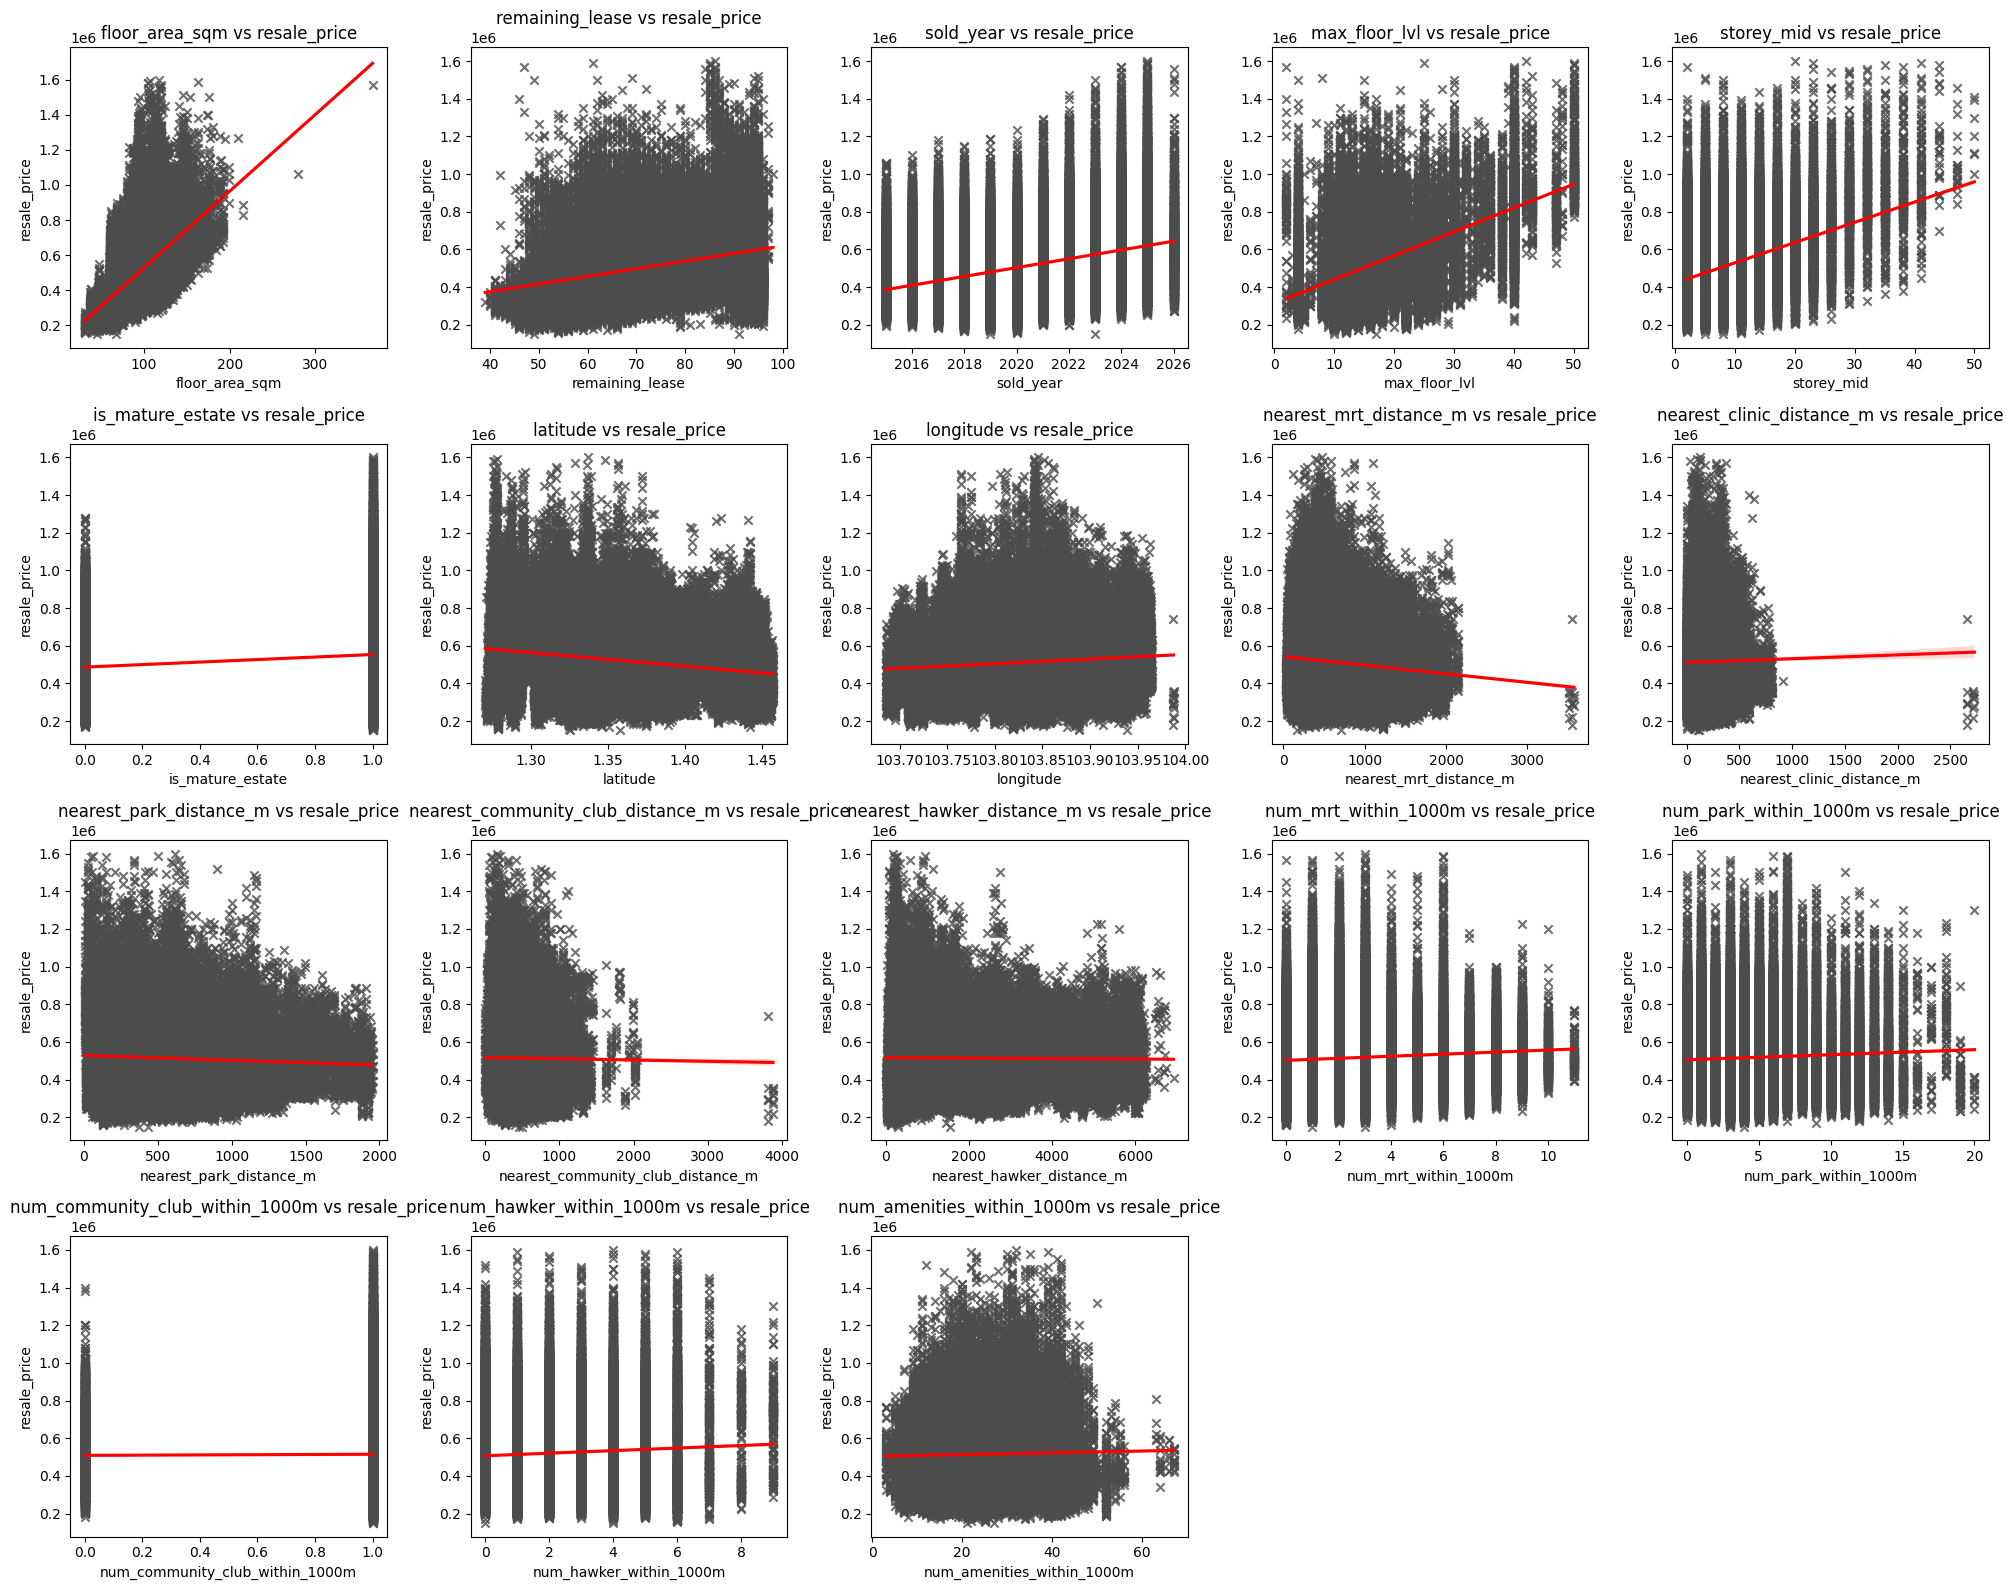

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get a sample of dataset as full DF takes quite a while
temp = hdb_df.sample(100000, random_state=42)

# Get list of numeric columns and select column to plot against
column_of_interest = 'resale_price'
other_columns = temp.select_dtypes(include=['int64', 'float64']).columns.drop(column_of_interest)

# Number of subplot columns
n_cols = 5

# Ceiling division so there are enough subplot rows
n_rows = (len(other_columns) + n_cols - 1) // n_cols

# Create figure with subplots
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(4 * n_cols, 4 * n_rows))

# Flatten axes array for easy looping
axs = axs.flatten()

# Loop through columns and create regplot
for i, col in enumerate(other_columns):
    sns.regplot(
        data=temp,
        x=col,
        y=column_of_interest,
        ax=axs[i],
        ci=99,
        marker="x",
        color=".3",
        line_kws={"color": "r"}
    )
    axs[i].set_title(f'{col} vs {column_of_interest}')

# Hide unused subplots
for i in range(len(other_columns), len(axs)):
    axs[i].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.show()

**Comments**:

- floor_area_sqm, remaining lease and max_floor_lvl seem to have positive correlation with resale_prices, which can be useful in the oerdis

In [34]:
# Create lists of relevant categorical and numerical columns allowing them to be treated differently
name_cols = ['matched_address', 'nearest_clinic_name', 
             'nearest_park_name', 'nearest_hawker_name',
             'nearest_mrt_name']

cat_cols = hdb_df.select_dtypes(include=['object']).columns.difference(name_cols)

/tmp/ipykernel_6828/159264783.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = hdb_df.select_dtypes(include=['object']).columns.difference(name_cols)


In [35]:
# Create new list of numeric columns, removing resale_price from columns to scale
num_cols_scale = ['floor_area_sqm',
 'sold_year',
 'remaining_lease',
 'max_floor_lvl']

In [36]:
# Select target column
target_col = 'resale_price'

# Ready X and y
X = hdb_df.loc[:, ~hdb_df.columns.isin([target_col])]
y = hdb_df[target_col]

# Split the data, 80-20 split with a random state included for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 54)


#### Creating a Pipeline 
Pipelines are essentially the backbone of efficient and effective data modeling, ensuring a streamlined, consistent, and flexible approach.

 - Streamlining Processes
   - Pipelines allow the combination of various steps like data preprocessing, feature extraction, and model training into one cohesive process.
 - Consistency and Reproducibility
    - They ensure consistent application of preprocessing and modeling steps for reliable results.
 - Ease of Modification
    - Pipelines allow for easy alterations or replacements of individual components without needing to redo the entire process.
 - Avoiding Data Leakage
     - They prevent data leakage during cross-validation by properly managing data preprocessing steps.
 - Simplifying Code
     - Pipelines contribute to more organized and readable code, making the data modeling process cleaner and more manageable.
 - Model Validation and Parameter Tuning
     - They work well with grid search and cross-validation for effective model optimization and validation.
 - Deployment Ready
     - Pipelines simplify the deployment process as they encapsulate all necessary steps in a model's development.
 - Flexibility
     - They are versatile, accommodating various data transformations and modeling techniques.



#### Preprocessing Pipeline

Feature scaling is important for methods that apply a regularization penalty like Ridge or Lasso regression.

The penalty applied is sum-of-squares in Ridge and sum-of-absolute values in Lasso. If features are on different scales, the regularization does not treat all features equally. Hence, scaling ensures that the regularization term is applied uniformly across all features.

Also, when features are on the same scale, we can more meaningfully compare the magnitude of coefficients to determine which features have more impact on the outcome.

However, in some cases, you might decide not to scale features - if the scale of the features is relevant to the problem (eg: a feature is bounded between 0 and 100 by definition), scaling may not be necessary and might even be misleading.

In [37]:
# Create instances of OneHotEncoder
cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

# Create pipeline of two scalers for numeric data
num_transformer = make_pipeline(RobustScaler(), MinMaxScaler())

# Create a final to apply transformations to subsets of columns
prepoc = make_column_transformer(
    (cat_transformer, cat_cols),
    (num_transformer, num_cols_scale)
)

# View Pipeline
prepoc

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [38]:
# Process X & y with pipeline
X_train_processed = prepoc.fit_transform(X_train)
X_test_processed = prepoc.transform(X_test)

In [39]:
# See what's in column 6
print("Train unique:", X_train.iloc[:, 6].unique())
print("Test unique:",  X_test.iloc[:, 6].unique())
print("Unknowns:", set(X_test.iloc[:, 6]) - set(X_train.iloc[:, 6]))

Train unique: [2023 2017 2021 2024 2019 2025 2020 2022 2018 2016 2015 2026]
Test unique: [2022 2015 2018 2019 2024 2016 2023 2020 2017 2021 2025 2026]
Unknowns: set()


In [40]:
# Check to see if it worked
print("Number of columns originally:", X.shape[1])
print("Number of columns after preprocessing:",X_train_processed.shape[1])

Number of columns originally: 31
Number of columns after preprocessing: 73


#### Creating a Base Multivariate Linear Regression Model & Evaluation 

In [41]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Instantiate the model
linear_model = LinearRegression()

# Define multiple scoring metrics (added RMSE + MAPE)
scoring = [
    'r2', 
    'neg_mean_absolute_error',
    'neg_mean_squared_error',           # For RMSE  
    'neg_mean_absolute_percentage_error' # For MAPE
]

# Get the cross validation scores
scores = cross_validate(
    linear_model, 
    X_train_processed, 
    y_train, 
    cv=5, 
    scoring=scoring, 
    return_train_score=False
)

# Calculate and round means
train_r2_mean = round(scores['test_r2'].mean(), 2)
train_mae_mean = round(-(scores['test_neg_mean_absolute_error'].mean()), 2)
train_rmse_mean = round(np.sqrt(-(scores['test_neg_mean_squared_error'].mean())), 2)
train_mape_mean = round(-(scores['test_neg_mean_absolute_percentage_error'].mean()) * 100, 2)

# Print all scores
print("Training R² score =", train_r2_mean)
print("Training MAE =", train_mae_mean) 
print("Training RMSE =", train_rmse_mean)
print("Training MAPE (%) =", train_mape_mean)

# View scores dictionary (unchanged)
scores

Training R² score = 0.85
Training MAE = 55503.58
Training RMSE = 71824.82
Training MAPE (%) = 11.83


{'fit_time': array([0.56163669, 0.61346245, 1.41290998, 0.59826517, 0.78944921]),
 'score_time': array([0.00358582, 0.0086    , 0.004287  , 0.00358605, 0.00433683]),
 'test_r2': array([0.84437136, 0.84799373, 0.85059364, 0.84569361, 0.84688905]),
 'test_neg_mean_absolute_error': array([-55829.42381914, -55477.91229052, -55293.18104163, -55604.01781598,
        -55313.36636156]),
 'test_neg_mean_squared_error': array([-5.19252200e+09, -5.16195775e+09, -5.11694410e+09, -5.21714571e+09,
        -5.10545579e+09]),
 'test_neg_mean_absolute_percentage_error': array([-0.11958744, -0.11810026, -0.11781165, -0.11803429, -0.11819716])}

In [42]:
import numpy as np

# Get rounded scores stored in variables
train_base_r2_mean = round(scores['test_r2'].mean(), 2)
train_base_mae_mean = round(-(scores['test_neg_mean_absolute_error'].mean()), 2)
train_base_rmse_mean = round(np.sqrt(-(scores['test_neg_mean_squared_error'].mean())), 2)
train_base_mape_mean = round(-(scores['test_neg_mean_absolute_percentage_error'].mean()) * 100, 2)

# Print scores to assess
print("Training R² score =", train_base_r2_mean)
print("Training MAE =", train_base_mae_mean)
print("Training RMSE =", train_base_rmse_mean)
print("Training MAPE (%) =", train_base_mape_mean)

Training R² score = 0.85
Training MAE = 55503.58
Training RMSE = 71824.82
Training MAPE (%) = 11.83


**Training R² Score = 0.85**

- R² measures the proportion of variance in the dependent variable explained by the model. 
- A score of 0.85 indicates that 85% of the variability in HDB prices is accounted for by the model, which is generally considered a strong fit. 
- That said, a high R² alone does not guarantee model quality — it neither confirms that the model is appropriate nor that its predictions are accurate.

**Training Mean Absolute Error (MAE) = $55,503.58**

- MAE represents the average absolute difference between predicted and actual values, regardless of direction. 
- Here, the model's predictions deviate by an average of $55,503.58. Given that HDB flats average around $500,000, this translates to roughly a 10% error — a meaningful margin that should be considered when evaluating the model's practical usefulness.


In [43]:
# Fitting model on data.
linear_model.fit(X_train_processed, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Predict y with fitted model
y_pred = linear_model.predict(X_test_processed)

# Calculate test set metrics (matching CV metrics)
test_base_mae_mean = round(mean_absolute_error(y_test, y_pred), 2)
test_base_rmse_mean = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
test_base_r2_mean = round(r2_score(y_test, y_pred), 2)
test_base_mape_mean = round(-(scores['test_neg_mean_absolute_percentage_error'].mean()) * 100, 2)

# Print test scores (matching training format)
print("Testing R² score =", test_base_r2_mean)
print("Testing MAE =", test_base_mae_mean)
print("Testing RMSE =", test_base_rmse_mean)
print("Testing MAPE (%) =", test_base_mape_mean)

Testing R² score = 0.85
Testing MAE = 55934.03
Testing RMSE = 72208.82
Testing MAPE (%) = 11.83


**Testing R² Score = 0.85**

- The testing R² mirrors the training score, indicating the model generalizes well to unseen data. - This consistency between training and testing performance is a strong indicator of a robust, well-fitted model.

**Testing MAE = $55,934.03**

- The marginal increase in MAE from training ($55,503.58) to testing ($55,934.03) is negligible, suggesting the model is not overfitting and maintains reliable predictive performance on new data.

**Overall**

- The close alignment between training and testing metrics — both in R² and MAE — reflects a model that is consistent, well-generalized, and not merely memorizing the training data. 
- The high R² demonstrates strong explanatory power, while the MAE provides a practical sense of the average prediction error in dollar terms.

#### Taking a look at the Feature Coefficients

In [45]:
# To Get importance of features in a DF:
# Get feature names
feature_names = prepoc.get_feature_names_out()

# Get coefficients
coefficients = linear_model.coef_

# Create empty Dictionary
feature_coefficients = {}

# For loop to print coefficient and put them into dict
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
    feature_coefficients[feature] = coef

# Include intercept in the dict
print(f"intercept: {linear_model.intercept_}")
feature_coefficients["intercept"] = linear_model.intercept_

onehotencoder__flat_model_3Gen: 22688.096954012908
onehotencoder__flat_model_Adjoined flat: 88601.50054327457
onehotencoder__flat_model_Apartment: 66192.60507462677
onehotencoder__flat_model_DBSS: 124125.80944642333
onehotencoder__flat_model_Executive Maisonette: 179208.68715901952
onehotencoder__flat_model_Improved: 13396.13129424304
onehotencoder__flat_model_Maisonette: 111292.88571074553
onehotencoder__flat_model_Model A: 13220.442198023622
onehotencoder__flat_model_Model A2: 24564.116135031254
onehotencoder__flat_model_Multi Generation: 78228.79479190886
onehotencoder__flat_model_New Generation: 39984.84440129529
onehotencoder__flat_model_Premium Apartment: 26486.386803346577
onehotencoder__flat_model_Simplified: 49601.87018527684
onehotencoder__flat_model_Standard: 23139.578702972536
onehotencoder__flat_model_Terrace: 385401.301512394
onehotencoder__flat_model_Type S1: 161670.88685495086
onehotencoder__flat_model_Type S2: 219000.52292950702
onehotencoder__flat_type_2 ROOM: -6935.4

In [46]:
# Converting to DataFrame
feature_coefficients_df = pd.DataFrame(list(feature_coefficients.items()), columns=['Feature', 'Coefficient'])
feature_coefficients_df.head()

,Feature,Coefficient
0,onehotencoder__flat_model_3Gen,22688.096954
1,onehotencoder__flat_model_Adjoined flat,88601.500543
2,onehotencoder__flat_model_Apartment,66192.605075
3,onehotencoder__flat_model_DBSS,124125.809446
4,onehotencoder__flat_model_Executive Maisonette,179208.687159


In [47]:
# Sorting the DataFrame by the absolute values of the 'Coefficient' column
feature_coefficients_df = feature_coefficients_df.sort_values(by='Coefficient', key=abs, ascending=False)
feature_coefficients_df.head(15)

,Feature,Coefficient
69,pipeline__floor_area_sqm,1.470016e+06
14,onehotencoder__flat_model_Terrace,3.854013e+05
70,pipeline__sold_year,2.846589e+05
71,pipeline__remaining_lease,2.773593e+05
16,onehotencoder__flat_model_Type S2,2.190005e+05
4,onehotencoder__flat_model_Executive Maisonette,1.792087e+05
51,onehotencoder__town_CHOA CHU KANG,-1.635599e+05
15,onehotencoder__flat_model_Type S1,1.616709e+05
62,onehotencoder__town_SEMBAWANG,-1.518976e+05
67,onehotencoder__town_WOODLANDS,-1.453960e+05


**Comments**

Model seems to make sense, as floor_area_sqm is the single strongest predictor of price, followed by whether the flat is a Terrace model, the year it was sold, and remaining lease.

#### Plots to Evaluate Model Performance ####
##### Residual Plot

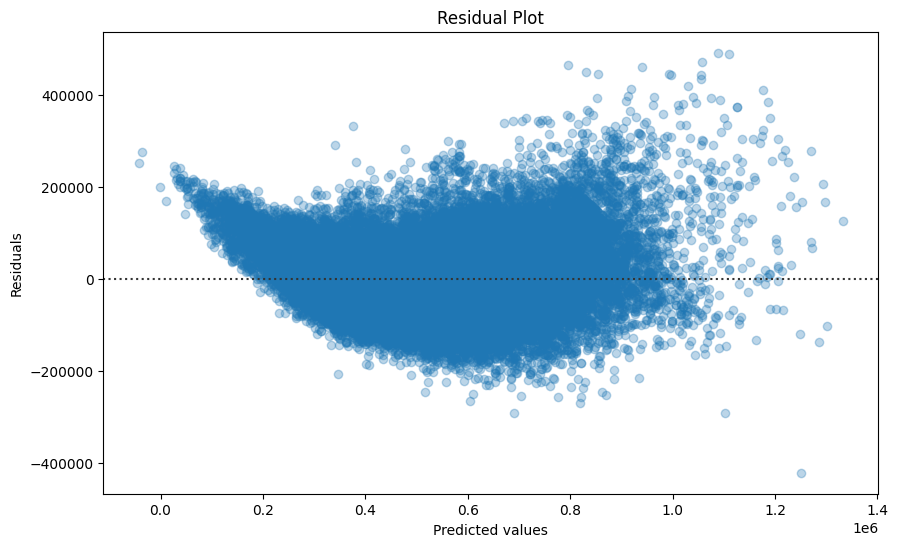

In [48]:
# Get residuals
residuals = y_test - y_pred

# Plot
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, scatter_kws={"alpha": 0.3})
plt.title('Residual Plot')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.show()

**Comments**

- The residuals display a clear fan-shaped pattern that widens as predicted values increase, which is a strong indicator of heteroscedasticity — the variance of errors is not constant across the range of predictions.
- There is a noticeable asymmetry in the residuals: the upper tail (positive residuals) extends further than the lower tail at higher predicted values, suggesting the model systematically underpredicts for higher-priced flats.
- The presence of negative predicted values on the left side is a red flag, suggesting the model is poorly specified at the lower end.
- Data points are densest around the 0.2-0.6 predicted value range, indicating the model performs relatively better in that mid-range bracket.

**Conclusion**

- The residual plot reveals two key OLS assumption violations: heteroscedasticity and poor model specification at the extremes. A log transformation of the target variable (resale_price) is strongly recommended to stabilise variance, and non-linear models such as gradient boosting or random forests may better capture the underlying price dynamics.

##### Histogram of Residuals

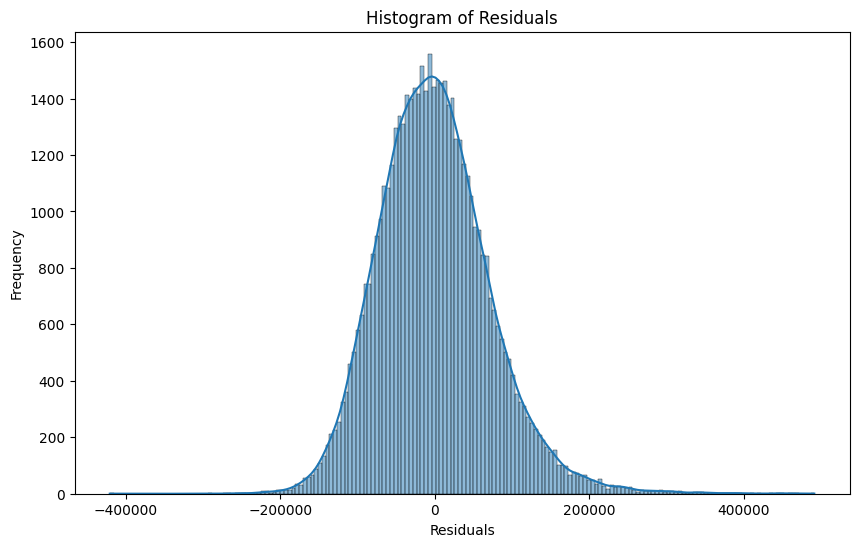

In [49]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

**Comments**

- The residuals form an approximately symmetrical, bell-shaped distribution centered around zero, with the fitted curve closely following a normal distribution. This suggests the residuals do not deviate significantly from normality — a key assumption of linear regression.

**Conclusion**

- Overall, the histogram indicates that the normality assumption is reasonably satisfied. The symmetry around zero reflects an absence of systematic bias in the model's predictions, and the tails show no signs of heavy skewness or extreme outliers, further supporting the model's suitability for the data.

##### Q-Q Plot

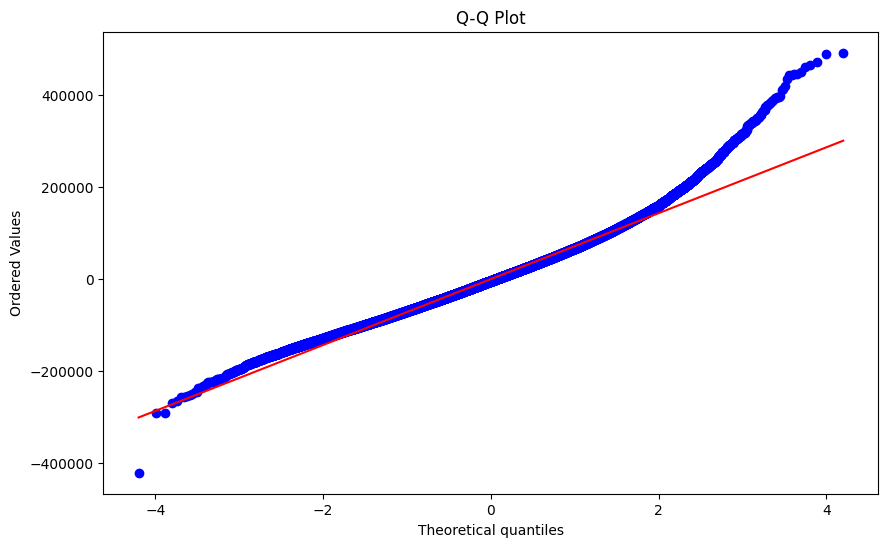

In [50]:
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

**Comments**

- The red reference line marks perfect normality, while the blue dots represent the actual data quantiles plotted against their theoretical counterparts. Points in the central region closely follow the reference line, indicating approximate normality there. However, deviations emerge in both tails — the lower tail dips below and the upper tail rises above the line — forming a slight S-shape that suggests the distribution has a higher peak and heavier tails than a normal distribution.

**Conclusion**

- While the center of the distribution appears approximately normal, the heavier tails indicated by the Q-Q plot raise concerns about the normality assumption. This may warrant variable transformations or alternative modeling approaches to better handle the distributional characteristics of the data.